# Facial Recognition Analysis Project

## Models (3 Max):

* Dlib (classical baseline)
* FaceNet (deep embedding)
* ArcFace (modern method)

## Dataset (1 Primary)

* LFW (Labeled Faces in the Wild)  BEST for undergrad

Avoid million-scale datasets.

## CV Analysis Component (Critical)
Analyze how vision factors affect recognition, e.g.:

Controlled Experiments
Modify images and test performance under:

* blur
* lighting change
* occlusion
* rotation
* resolution reduction

## Threshold Analysis
Face verification depends on similarity threshold.

Embedding distance threshold → Accuracy tradeoff

Produce ROC curves.

In [1]:
# Install packages
!pip install scikit-learn dlib facenet-pytorch Pillow tensorflow numpy opencv-python scikit-learn matplotlib arcface face_recognition

# Load and Visualize the Dataset

In [3]:
# Load LFW dataset
from sklearn.datasets import fetch_lfw_pairs

fetch_lfw_pairs = fetch_lfw_pairs(color = True, resize = 1)

In [4]:
pairs = fetch_lfw_pairs.pairs
labels = fetch_lfw_pairs.target
target_names = fetch_lfw_pairs.target_names

In [5]:
pairs[0][0].shape

(125, 94, 3)

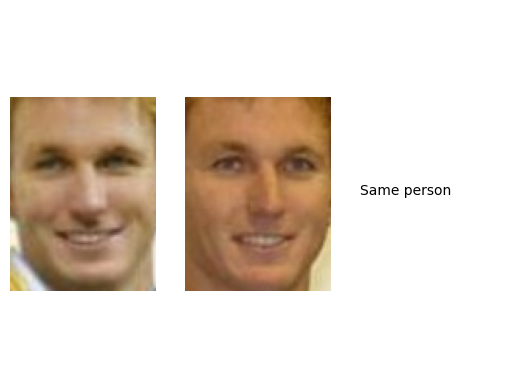

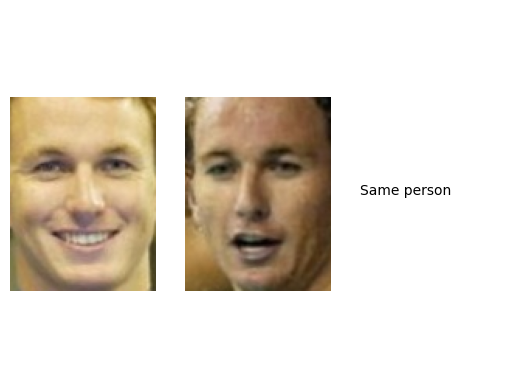

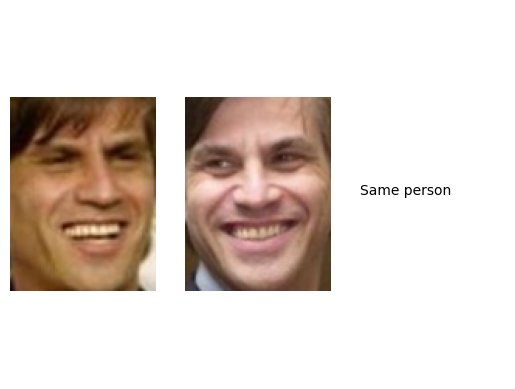

In [6]:
import matplotlib.pyplot as plt

actuals = []
predictions = []

for i in range(3):
   pair = pairs[i]
   img1 = pair[0]
   img2 = pair[1]

   fig = plt.figure()

   ax1 = fig.add_subplot(1,3,1)
   ax1.set_axis_off()
   plt.imshow(img1)

   ax2 = fig.add_subplot(1,3,2)
   ax2.set_axis_off()
   plt.imshow(img2)

   ax3 = fig.add_subplot(1,3,3)
   ax3.set_axis_off()
   plt.text(0, 0.50, target_names[labels[i]])

   plt.show()

# Preprocess the Data

In [7]:
import cv2
import numpy as np

In [9]:
# Blurred images dataset
blurred_pairs = pairs.copy()

for i, pair in enumerate(blurred_pairs):
  for j in range(2):
    img = pair[j]
    blurred_img = cv2.GaussianBlur(img, (5, 5), 0)
    blurred_pairs[i][j] = blurred_img

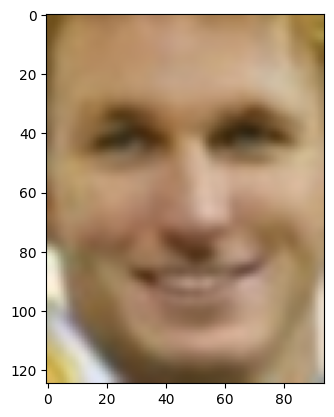

In [10]:
# Blurring test
plt.imshow(blurred_pairs[0][0])

In [11]:
# Lighting change images dataset
lighting_change_pairs = pairs.copy()

for i, pair in enumerate(lighting_change_pairs):
  for j in range(2):
    img = pair[j]

    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Adjust Brightness
    adj_value = 0.25
    v = cv2.add(v, adj_value) # cv2.add handles the 255 saturation limit automatically

    # Merge and Convert Back
    final_hsv = cv2.merge((h, s, v))
    result = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

    lighting_change_pairs[i][j] = result

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04620384..1.25].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.4075604e-07..1.1794118].


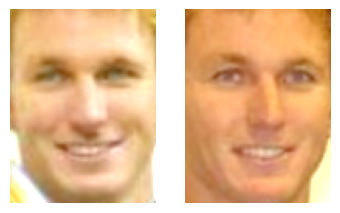

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08792099..1.25].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.1526181e-07..1.195098].


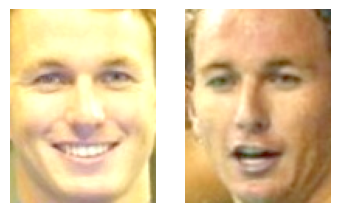

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.1720635e-07..1.25].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07232303..1.25].


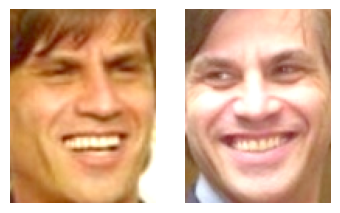

In [12]:
# Test lighting change
for i in range(3):
  pair = lighting_change_pairs[i]
  img1 = pair[0]
  img2 = pair[1]

  fig = plt.figure()

  ax1 = fig.add_subplot(1,3,1)
  ax1.set_axis_off()
  plt.imshow(img1)

  ax2 = fig.add_subplot(1,3,2)
  ax2.set_axis_off()
  plt.imshow(img2)

  plt.show()

In [13]:
# Occlusion dataset
import random

occlusion_pairs = pairs.copy()
height, width = occlusion_pairs[0][0].shape[:2]
print(height, width)
short_len = 30
long_len = 80

for i, pair in enumerate(occlusion_pairs):
  orientation = random.randint(0, 1)
  x_len = short_len if orientation else long_len
  y_len = long_len if orientation else short_len
  top_left_x = random.randint(0, height - x_len)
  top_left_y = random.randint(0, height - y_len)
  bottom_right_x = top_left_x + x_len
  bottom_right_y = top_left_y + y_len

  for j in range(2):
    img = pair[j]

    cv2.rectangle(img, (top_left_x, top_left_y), (bottom_right_x, bottom_right_y), (0, 0, 0), -1)

125 94


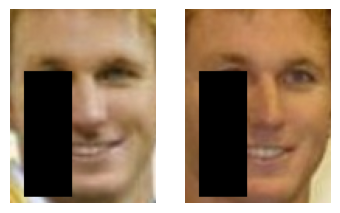

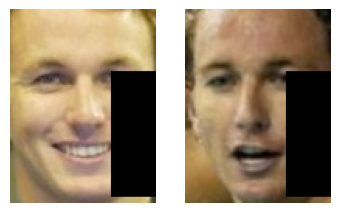

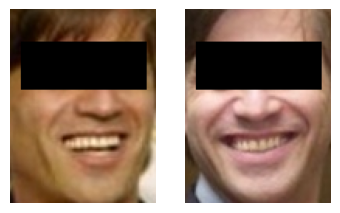

In [14]:
# Test occlusion
for i in range(3):
  pair = occlusion_pairs[i]
  img1 = pair[0]
  img2 = pair[1]

  fig = plt.figure()

  ax1 = fig.add_subplot(1,3,1)
  ax1.set_axis_off()
  plt.imshow(img1)

  ax2 = fig.add_subplot(1,3,2)
  ax2.set_axis_off()
  plt.imshow(img2)

  plt.show()

In [15]:
# Rotation dataset
rotation_pairs = pairs.copy()
height, width = rotation_pairs[0][0].shape[:2]

for i, pair in enumerate(rotation_pairs):
  for j in range(2):
    img = rotation_pairs[i][j]

    center = (width // 2, height // 2)

    angle = random.uniform(5.0, 355.0)
    scale = 1.0
    matrix = cv2.getRotationMatrix2D(center, angle, scale)

    rotation_pairs[i][j] = cv2.warpAffine(img, matrix, (width, height))

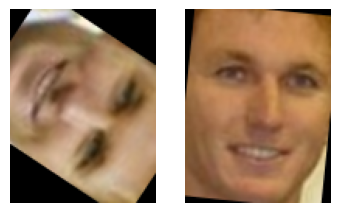

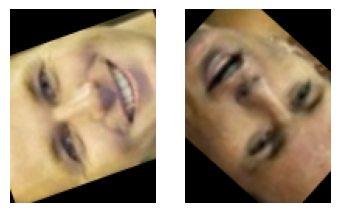

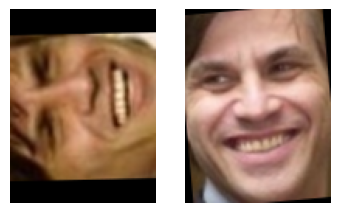

In [16]:
# Test rotation
for i in range(3):
  pair = rotation_pairs[i]
  img1 = pair[0]
  img2 = pair[1]

  fig = plt.figure()

  ax1 = fig.add_subplot(1,3,1)
  ax1.set_axis_off()
  plt.imshow(img1)

  ax2 = fig.add_subplot(1,3,2)
  ax2.set_axis_off()
  plt.imshow(img2)

  plt.show()

In [17]:
# resolution reduction dataset
resolution_reduced_pairs = np.zeros_like(pairs)

for i, pair in enumerate(pairs):
  for j in range(2):
    img = pair[j]

    height, width = img.shape[:2]

    # Downscale to a lower resolution
    scale = 0.9
    small_img = cv2.resize(img, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    # Upscale back to original dimensions
    low_res_img = cv2.resize(small_img, (width, height), interpolation=cv2.INTER_NEAREST)

    resolution_reduced_pairs[i][j] = low_res_img

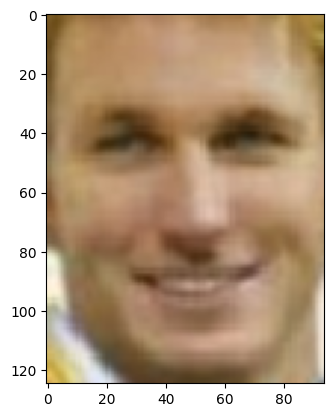

In [18]:
# Test resolution reduction
plt.imshow(resolution_reduced_pairs[0][0])

# Load the Models

## Dlib

In [ ]:
# Load Dlib model
import face_recognition

def get_dlib_embedding(img):
  return face_recognition.face_encodings(image, model="large")

# img = face_recognition.load_image_file(image_path)
# face_encoding = face_recognition.face_encodings(img)[0]
# results = face_recognition.compare_faces([ ... list of encodings of the same face ... ], unknown_face_encoding)
# if results[0] == True: print("yup they match")

# Sources for this model
# https://blog.dlib.net/2017/02/high-quality-face-recognition-with-deep.html
# https://scholar.google.com/citations?view_op=view_citation&hl=en&user=3NztoZAAAAAJ&citation_for_view=3NztoZAAAAAJ:8k81kl-MbHgC



## FaceNet

* Expects normalized 160x160px in RGB

In [ ]:
# Preprocess images specifically for FaceNet

def facenet_preprocess_img(img):
  # Resize the image to 160x160 pixels by adding black borders around the image
  img = cv2.copyMakeBorder(img, top=18, bottom=17, left=33, right=33, borderType=cv2.BORDER_CONSTANT, value=[0, 0, 0])

  # Normalize the pixel values
  img = img.astype('float32') / 255.0

  # Expand dimensions to match the input shape of FaceNet (1, 160, 160, 3)
  img = np.expand_dims(img, axis=0)

  return img

def facenet_preprocess_pairs(pairs):
  face_net_pairs = np.zeros((2200, 2, 160, 160, 3), dtype=np.int64)

  for i, pair in enumerate(pairs):
    for j in range(2):
      img = pair[j]
      face_net_pairs[i][j] = facenet_preprocess_img(img)

  return face_net_pairs


facenet_blurred_pairs = facenet_preprocess_pairs(blurred_pairs)
facenet_lighting_change_pairs = facenet_preprocess_pairs(lighting_change_pairs)
facenet_occlusion_pairs = facenet_preprocess_pairs(occlusion_pairs)
facenet_rotation_pairs = facenet_preprocess_pairs(rotation_pairs)
facenet_resolution_reduced_pairs = facenet_preprocess_pairs(resolution_reduced_pairs)

In [ ]:
# Test facenet pairs
for pairs in (facenet_blurred_pairs, facenet_lighting_change_pairs, facenet_occlusion_pairs, facenet_rotation_pairs, facenet_resolution_reduced_pairs)
  for i in range(1):
    pair = pairs[i]
    img1 = pair[0]
    img2 = pair[1]

    fig = plt.figure()

    ax1 = fig.add_subplot(1,3,1)
    ax1.set_axis_off()
    plt.imshow(img1)

    ax2 = fig.add_subplot(1,3,2)
    ax2.set_axis_off()
    plt.imshow(img2)

    plt.show()

In [ ]:
# Load FaceNet model
from keras.models import load_model

print("Loading FaceNet Model...")
model = load_model('facenet_keras.h5')
print("FaceNet Model Loaded Successfully.")

## ArcFace

In [ ]:
# Load ArcFace model
from insightface.app import FaceAnalysis

# using largest model to maximize accuracy
arcface = FaceAnalysis(name="buffalo_l")
arcface.prepare(ctx_id=0)

def get_arcface_embedding(img):
  return arcface.get(img)

# To use:
# face_rec.calc_emb("img_path")
# You should be able to feed in an array of images (or image paths)
# This does facial recognition only.

